# Stage 05 — EDA and statistics (train period only)
Where is the signal? store vs article, autocorrelation, seasonality, shelf life. Test weeks are not used.

In [1]:
import sys
sys.path.insert(0, "../../plugins/dslc/skills/dslc/scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf, statsmodels.api as sm
from scipy import stats
from dslc_style import apply_style, SERIES, INK, save
apply_style()
p = pd.read_parquet("data/processed/weekly_panel.parquet")
tr = p[p.split == "train"].copy()
print(tr.shape, tr.week.min().date(), tr.week.max().date())
print(tr.units.describe().round(2).to_string())

(5220, 20) 2024-04-29 2024-12-30
count    5220.00
mean       11.22
std         9.70
min         0.00
25%         5.00
50%         9.00
75%        15.00
max        77.00


## 1. How much variance is store vs article? (ANOVA, eta-squared)

In [2]:
res = {}
for f in ["C(ARTICLE)", "C(SITE_NAME)", "C(division)", "C(month)", "C(ARTICLE) + C(SITE_NAME)", "C(ARTICLE) * C(SITE_NAME)"]:
    m = smf.ols(f"units ~ {f}", tr).fit(); res[f] = (round(m.rsquared, 3), round(m.rsquared_adj, 3), int(m.df_model))
print(pd.DataFrame(res, index=["R2", "adjR2", "df"]).T.to_string())
a = sm.stats.anova_lm(smf.ols("units ~ C(ARTICLE) + C(SITE_NAME)", tr).fit(), typ=2)
a["eta_sq"] = a["sum_sq"] / a["sum_sq"].sum(); print(a.round(4).to_string())

                              R2  adjR2     df
C(ARTICLE)                 0.536  0.534   28.0
C(SITE_NAME)               0.000 -0.000    4.0
C(division)                0.045  0.044    2.0
C(month)                   0.002  0.000    8.0
C(ARTICLE) + C(SITE_NAME)  0.537  0.534   32.0
C(ARTICLE) * C(SITE_NAME)  0.547  0.534  144.0
                   sum_sq      df         F  PR(>F)  eta_sq
C(ARTICLE)    263140.5080    28.0  214.3728  0.0000  0.5362
C(SITE_NAME)     239.3303     4.0    1.3648  0.2435  0.0005
Residual      227392.6031  5187.0       NaN     NaN  0.4633


## 2. Store differences (total units per store-week) and month effect

In [3]:
st_week = tr.groupby(["SITE_NAME", "week"]).units.sum().reset_index()
print(st_week.groupby("SITE_NAME").units.agg(["mean", "std"]).round(1).to_string())
print("Kruskal-Wallis store:", stats.kruskal(*[g.units.values for _, g in st_week.groupby("SITE_NAME")]))
tot_week = tr.groupby("week").units.sum().reset_index(); tot_week["month"] = tot_week.week.dt.month
print("Kruskal-Wallis month (total units):", stats.kruskal(*[g.units.values for _, g in tot_week.groupby("month")]))
x = np.arange(len(tot_week)); sl = stats.linregress(x, tot_week.units)
print(f"trend in total weekly units: slope {sl.slope:.2f}/wk, p={sl.pvalue:.3f}")

                    mean   std
SITE_NAME                     
East Fresh Store   328.8  52.3
Metro Fresh Store  324.1  44.0
RVM1 Fresh Store   332.3  59.8
RVM2 Fresh Store   328.0  47.4
West Fresh Store   314.2  55.4
Kruskal-Wallis store: KruskalResult(statistic=np.float64(1.5858880877895198), pvalue=np.float64(0.8113262230453163))
Kruskal-Wallis month (total units): KruskalResult(statistic=np.float64(9.188964340885699), pvalue=np.float64(0.3266069254902147))
trend in total weekly units: slope -2.40/wk, p=0.181


## 3. Is there week-to-week memory after removing the article-store level?

In [4]:
tr["level"] = tr.groupby(["SITE_NAME", "ARTICLE"]).units.transform("mean")
tr["resid"] = tr.units - tr.level
tr["resid_l1"] = tr.groupby(["SITE_NAME", "ARTICLE"]).resid.shift(1)
ok = tr.dropna(subset=["resid_l1"])
r, pv = stats.pearsonr(ok.resid, ok.resid_l1); print(f"lag-1 autocorr of residuals: r={r:.3f} p={pv:.3f}")
r2 = stats.pearsonr(tr.units, tr.lag1)[0]; print(f"raw units vs lag1 corr: {r2:.3f}")

lag-1 autocorr of residuals: r=-0.039 p=0.005
raw units vs lag1 corr: 0.530


## 4. Noise: overdispersion (variance / mean) and the achievable floor

In [5]:
ser = tr.groupby(["SITE_NAME", "ARTICLE"]).units.agg(["mean", "var"])
ser["disp"] = ser["var"] / ser["mean"]
print("variance/mean per series: median", round(ser.disp.median(), 2), "(1 = Poisson)")
# in-sample floor: WAPE of predicting each series its own train mean
floor = np.abs(tr.units - tr.level).sum() / tr.units.sum(); print("WAPE using true series mean (in-sample floor-ish):", round(floor, 3))

variance/mean per series: median 3.79 (1 = Poisson)
WAPE using true series mean (in-sample floor-ish): 0.441


## 5. Shelf life and category

In [6]:
art = tr.groupby("ARTICLE").agg(mean_units=("units", "mean"), shelf=("shelf_life_days", "first"), rate=("avg_rate", "first"), div=("division", "first"))
print("corr(mean units, shelf life) spearman:", stats.spearmanr(art.mean_units, art.shelf_life_days if "shelf_life_days" in art else art.shelf))
print("corr(mean units, price) spearman:", stats.spearmanr(art.mean_units, art.rate))
print(tr.groupby("division").units.agg(["mean", "std", "count"]).round(2).to_string())
print("Kruskal division:", stats.kruskal(*[g.units.values for _, g in tr.groupby("division")]))

corr(mean units, shelf life) spearman: SignificanceResult(statistic=np.float64(-0.057984926198909714), pvalue=np.float64(0.7651121883420339))
corr(mean units, price) spearman: SignificanceResult(statistic=np.float64(-0.35960591133004915), pvalue=np.float64(0.05536423851599812))
               mean    std  count
division                         
Dairy & Milk   8.96   7.01   1260
Fruits        10.27   8.69   2160
Vegetables    13.96  11.65   1800
Kruskal division: KruskalResult(statistic=np.float64(164.46527727202485), pvalue=np.float64(1.9356142380089002e-36))


'figures/05_autocorr.png'

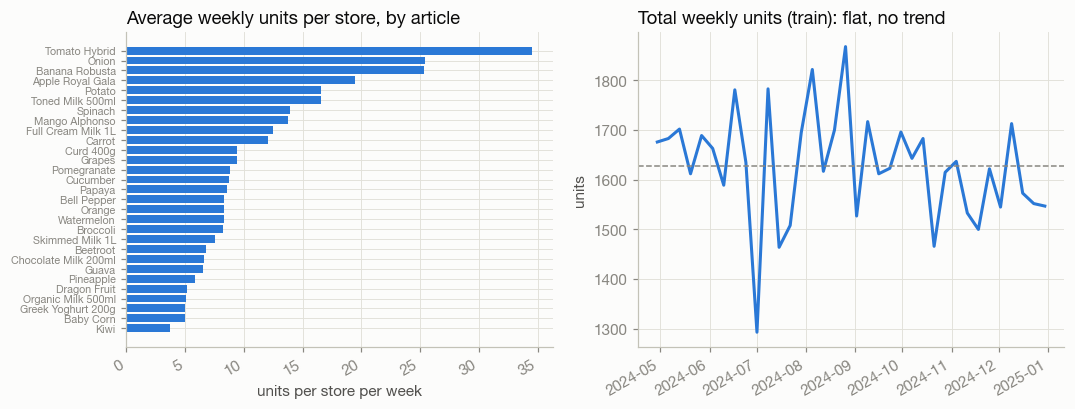

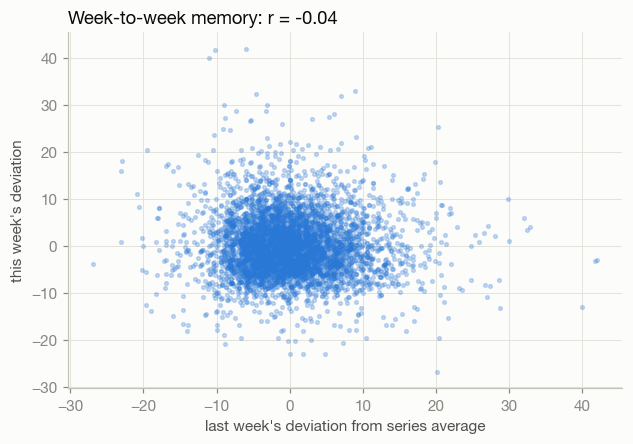

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
order = art.sort_values("mean_units").index
ax[0].barh(order, art.loc[order, "mean_units"], color=SERIES[0]); ax[0].set_title("Average weekly units per store, by article"); ax[0].set_xlabel("units per store per week"); ax[0].tick_params(axis="y", labelsize=7)
tw = tr.groupby("week").units.sum(); ax[1].plot(tw.index, tw.values, color=SERIES[0]); ax[1].axhline(tw.mean(), color=INK["muted"], ls="--", lw=1)
ax[1].set_title("Total weekly units (train): flat, no trend"); ax[1].set_ylabel("units"); fig.autofmt_xdate()
save(fig, "05_signal")
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(ok.resid_l1, ok.resid, s=6, alpha=.25, color=SERIES[0]); ax.set_xlabel("last week's deviation from series average"); ax.set_ylabel("this week's deviation")
ax.set_title(f"Week-to-week memory: r = {r:.2f}"); save(fig, "05_autocorr")